# Processing Pipeline

In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

import pandas as pd
from tgf import Task, TaskGroup, Flag, AbstractTask, AbstractFlag, Pipeline, BaseFlag
from plotting import plotMatrix, plotReport
import executors as ex

import warnings

warnings.filterwarnings("ignore")


Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
dataPath = str(Path.cwd()) + r"\data\csv" + "\\"
picklePath = str(Path.cwd()) + r"\out\pickle_objects\processing_pipeline" + "\\"
plotPath = str(Path.cwd()) + r"\out\plots\processing_pipeline" + "\\"
tablePath = str(Path.cwd()) + r"\out\tables\processing_pipeline" + "\\"

In [3]:
file = r"Apple iDevices\Apple iPhone\Apple_iPhone_(online).csv"
data = pd.read_csv(dataPath + file, encoding='cp1252')

In [4]:
flags = []

flag_preProcessing = Flag("Pre Processing")
flag_dummy = Flag("Dummy Processing")
flag_modeling = Flag("Modeling")

flags.extend([flag_preProcessing, flag_dummy, flag_modeling])

In [5]:
AnalysisPipeline = TaskGroup('Processing Pipeline', idempotency=True)

generalPreProcessing = TaskGroup('Pre Processing', 10, idempotency=True, flags=flag_preProcessing)

columns = ['Time', 'Source', 'Destination', 'Channel', 'Length Packet', 'Length Header', 'AD Type',
           'Company ID', 'MS Data', 'UUID', 'Service Data', 'PDU']

task_orderColumns = Task("Select and order columns", priority=10,
                         executor=ex.keepColumns(columns=columns))

taskGroup_Company_and_UUID = TaskGroup('Company ID and UUID', priority=15, idempotency=True)

task_fillNa_Company = Task("Fill Company ID with None", priority=10,
                           executor=ex.fillNa(fillValue="None",
                                              columns=['Company ID']
                                              )
                           )

task_fillNa_UUID = Task("Fill UUID with None", priority=20,
                        executor=ex.fillNa(fillValue="None",
                                           columns=['UUID']
                                           )
                        )

companies = {'Apple, Inc.': 'Apple', 'Tile, Inc.': 'Tile', 'Samsung Electronics Co., Ltd.': 'Samsung',
             'Apple Inc.': 'Apple', 'Google LLC': 'Google'}

task_ReplaceCompanyID = Task("Replace Company IDs", priority=30,
                             executor=ex.StringReplace(column='Company ID', replace=companies))
task_ReplaceCompanyUUID = Task("Replace Company UUIDs", priority=40,
                               executor=ex.StringReplace(column='UUID', replace=companies))

taskGroup_Company_and_UUID.addAll([task_fillNa_Company, task_fillNa_UUID, task_ReplaceCompanyID, task_ReplaceCompanyUUID
                                   ])

taskGroup_MS_Data = TaskGroup("MS Data Processing", priority=20, idempotency=True)

task_convert_fillNa_MSData = Task("Fill MS Data with empty String", priority=10,
                                  executor=ex.fillNa(fillValue="",
                                                     columns=['MS Data']
                                                     )
                                  )

task_length_MS_Data = Task("Length of MS Data", priority=20,
                           executor=ex.convertToBitLength('MS Data', newColumn='Length MS Data')
                           )

task_Continuity_Type = Task("Continuity Type", priority=30,
                            executor=ex.extractAppleDataType(companyColumn="Company ID",
                                                             company='Apple',
                                                             dataColumn='MS Data',
                                                             typeColumn='Continuity Type',
                                                             noneValue="None")
                            )

task_drop_MS_Data = Task("Drop MS Data Column", priority=40,
                         executor=ex.dropColumns(columns=['MS Data'])
                         )

taskGroup_MS_Data.addAll([task_convert_fillNa_MSData, task_length_MS_Data, task_Continuity_Type, task_drop_MS_Data])

taskGroup_ServiceData = TaskGroup("Service Data Processing", priority=25, idempotency=True)

task_convert_fillNa_ServiceData = Task("Fill Service Data with empty String", priority=10,
                                       executor=ex.fillNa(fillValue="",
                                                          columns=['Service Data']
                                                          )
                                       )

task_length_ServiceData = Task("Length of Service Data", priority=20,
                               executor=ex.convertToBitLength(column='Service Data', newColumn='Length Service Data')
                               )

task_Samsung_Type = Task("Samsung Type", priority=30,
                         executor=ex.extractSamsungDataType(companyColumn="UUID",
                                                            company='Samsung',
                                                            dataColumn='Service Data',
                                                            typeColumn='SmartTag Type',
                                                            noneValue="None")
                         )

task_drop_Service_Data = Task("Drop Service Data Column", priority=40,
                              executor=ex.dropColumns(columns=['Service Data'])
                              )

taskGroup_ServiceData.addAll(
    [task_convert_fillNa_ServiceData, task_length_ServiceData, task_Samsung_Type, task_drop_Service_Data])

task_fillNa_Numeric = Task("Fill Numeric NA with 0", priority=30,
                           executor=ex.fillNa(fillValue="None",
                                              columns=['Length Packet', 'Length Header']
                                              )
                           )

task_fillNa_String = Task("Fill String NA with None", priority=40, executor=ex.fillNa(fillValue="None"))

task_DummiesBroadcast = Task("Broadcast", priority=50,
                             executor=ex.createDummies(column='Destination',
                                                       labels={'ff:ff:ff:ff:ff:ff': 'Broadcast'},
                                                       prefix='', prefix_sep='',
                                                       dropColumn=True
                                                       )
                             )

task_toDatetime = Task("Datetime conversion", priority=60,
                       executor=ex.toDateTime(column="Time",
                                              unit='s'
                                              )
                       )

task_orderDataFrame = Task("Order DataFrame", priority=80,
                           executor=ex.orderDataFrame(column="Time",
                                                      ascending=True
                                                      )
                           )

task_convertObjectToString = Task("Convert object type to string", priority=90, executor=ex.convertObjectToString())

generalPreProcessing.addAll(
    [task_orderColumns, taskGroup_Company_and_UUID, task_toDatetime, task_convertObjectToString, task_fillNa_Numeric,
     task_fillNa_String, task_orderDataFrame, taskGroup_MS_Data, task_DummiesBroadcast,
     taskGroup_ServiceData])
AnalysisPipeline.add(generalPreProcessing)

AnalysisPipeline.print(flags=True, priority=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string


In [6]:
DummyProcessing = TaskGroup("Dummy Processing", priority=20, idempotency=True, flags=flag_dummy)

task_DummiesChannel = Task("Dummies Channel", priority=30,
                           executor=ex.createDummies(column='Channel',
                                                     labels=[37, 38, 39],
                                                     prefix="CH",
                                                     splitting=False,
                                                     dropColumn=True,
                                                     NoneValue='None')
                           )

AD_Types = ['Manufacturer Specific',
            'Flags',
            'Tx Power Level',
            'Service Data - 16 bit UUID',
            '16-bit Service Class UUIDs',
            '16-bit Service Class UUIDs (incomplete)'
            ]

task_DummiesAdType = Task("Dummies AD Type", priority=40,
                          executor=ex.createDummies(column='AD Type',
                                                    labels=AD_Types, prefix='AD',
                                                    splitting=True,
                                                    OtherColumn=True,
                                                    dropColumn=True,
                                                    NoneValue='None')
                          )

task_DummiesCompany = Task("Dummies Company", priority=50,
                           executor=ex.createDummies(column='Company ID',
                                                     labels=['Apple'],
                                                     prefix="COMP",
                                                     splitting=False,
                                                     OtherColumn=True,
                                                     dropColumn=True,
                                                     NoneValue='None')
                           )

task_DummiesUUID = Task("Dummies UUID", priority=55,
                        executor=ex.createDummies(column='UUID',
                                                  labels=['Apple', 'Samsung', 'Tile', 'Google'],
                                                  prefix="UUID",
                                                  splitting=True,
                                                  OtherColumn=True,
                                                  dropColumn=True,
                                                  NoneValue='None')
                        )

InfoTypes = ['ADV_IND',
             'ADV_DIRECT_IND',
             'ADV_NONCONN_IND',
             'ADV_SCAN_IND',
             'SCAN_REQ',
             'SCAN_RSP',
             ]

task_DummiesInfo = Task("Dummies PDU Type", priority=70,
                        executor=ex.createDummies(column='PDU',
                                                  labels=InfoTypes,
                                                  prefix='PDU',
                                                  splitting=False,
                                                  OtherColumn=True,
                                                  dropColumn=True,
                                                  NoneValue='None')
                        )

continuityTypes = ['07', '09', '10', '12', '16']

task_DummiesContinuity = Task("Dummies Continuity Type", priority=80,
                              executor=ex.createDummies(column='Continuity Type',
                                                        labels=continuityTypes,
                                                        prefix='CT',
                                                        splitting=False,
                                                        OtherColumn=True,
                                                        dropColumn=False,
                                                        NoneValue='None')
                              )

SmartTagTypes = ['1', '3', '5']

task_DummiesSmartTagType = Task("Dummies SmartTag Type", priority=90,
                                executor=ex.createDummies(column='SmartTag Type',
                                                          labels=SmartTagTypes,
                                                          prefix='ST',
                                                          splitting=False,
                                                          OtherColumn=True,
                                                          dropColumn=True,
                                                          NoneValue='None')
                                )

DummyProcessing.addAll(
    [task_DummiesCompany, task_DummiesUUID, task_DummiesChannel, task_DummiesAdType,
     task_DummiesInfo, task_DummiesContinuity, task_DummiesSmartTagType])

AnalysisPipeline.add(DummyProcessing)
AnalysisPipeline.print(flags=True, priority=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type


In [7]:
taskGroup_Modeling = TaskGroup("Modeling", priority=80, idempotency=True, flags=flag_modeling)
task_dropColumns = Task("Drop Columns", priority=10, executor=ex.dropColumns(columns=['Source', 'Time']))
task_dropColumns_Continuity = Task("Drop Column Continuity", priority=0,
                                   executor=ex.dropColumns(columns=['Continuity Type']))
taskGroup_Modeling.addAll([task_dropColumns, task_dropColumns_Continuity])

AnalysisPipeline.add(taskGroup_Modeling)
AnalysisPipeline.print(flags=True, priority=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	80 Modeling: Modeling
		0 Drop Column Continuity
		10 Drop Columns


In [8]:
temp = AnalysisPipeline.execute(data.copy(deep=True))
temp.info()

<class 'pandas.DataFrame'>
Index: 597429 entries, 0 to 597428
Data columns (total 39 columns):
 #   Column                                      Non-Null Count   Dtype
---  ------                                      --------------   -----
 0   Length Packet                               597429 non-null  int64
 1   Length Header                               597429 non-null  int64
 2   Length MS Data                              597429 non-null  int64
 3   Length Service Data                         597429 non-null  int64
 4   Broadcast                                   597429 non-null  int64
 5   CH 37                                       597429 non-null  int64
 6   CH 38                                       597429 non-null  int64
 7   CH 39                                       597429 non-null  int64
 8   AD Manufacturer Specific                    597429 non-null  int64
 9   AD Flags                                    597429 non-null  int64
 10  AD Tx Power Level                   

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neural_network import MLPClassifier
from copy import deepcopy


def filesToDataFrame(filesDict: dict[str:str], config: AbstractTask, filePath: str = dataPath,
                     shuffle: bool = False) -> pd.DataFrame:
    dataset = pd.DataFrame()

    for f in filesDict:
        new_dataset = Pipeline().setPath(filePath + f).setTask(config).loadData().run(flag=filesDict[f])
        dataset = pd.concat([dataset, new_dataset])

    if shuffle:
        dataset = dataset.sample(frac=1, random_state=1)

    dataset.reset_index(drop=True, inplace=True)

    return dataset


def semiSupervisedLearning(dataset: pd.DataFrame, threshold: float, labelColumn: str = 'Label',
                           model=MLPClassifier(max_iter=200, verbose=False, random_state=1, tol=0.00001,
                                               early_stopping=True),
                           scaler=MinMaxScaler()
                           ):
    Y = dataset[labelColumn]
    X = dataset.drop([labelColumn], axis=1)

    scalerSelfTrain = scaler
    X = scalerSelfTrain.fit_transform(X)

    selfTrainer = SelfTrainingClassifier(model, threshold=threshold, max_iter=5, verbose=True)
    selfTrainer.fit(X, Y)

    return selfTrainer, scalerSelfTrain


def evaluateModel(model, scaler, dataset: pd.DataFrame, name: str, path_plot: str = plotPath,
                  path_table: str = tablePath, labelColumn: str = 'Label'):
    Y = dataset[labelColumn]
    X = dataset.drop([labelColumn], axis=1)
    labels = sorted(list(Y.unique()))

    X = scaler.transform(X)
    y_pred = model.predict(X)

    print("\n")
    plotReport(Y, y_pred, labels, name=name, savePath=path_table)
    plotMatrix(Y, y_pred, labels, name=name, savePath=path_plot, dpi=100)


def nearbyTrackerConfigFactory(BaseConfig: TaskGroup, firstDevice: str, secondDevice: str,
                               parentFlags: list[AbstractFlag], priority: int = 30,
                               selection: slice = slice(0), sourceColumn: str = 'Source', labelColumn: str = 'Label'):
    label_Traker_nearby_Flag = Flag(name="Label nearby Tracker Flag", parents=parentFlags)
    label_Unknown_Flag = Flag("Unknown Label Flag", parents=parentFlags)

    taskGroup_Labeling = TaskGroup("Labeling", priority=priority, idempotency=True)

    task_Label_Unknown = Task("Label Unknown", executor=ex.labeling(label=-1, labelColumn=labelColumn),
                              flags=label_Unknown_Flag, )

    task_Label_Tracker_nearby = Task("Label nearby Tracker",
                                     executor=ex.labelMultipleDevices(firstDevice=firstDevice,
                                                                      secondDevice=secondDevice, selection=selection,
                                                                      source=sourceColumn, labelColumn=labelColumn)
                                     , flags=label_Traker_nearby_Flag)

    taskGroup_Labeling.addAll([task_Label_Unknown, task_Label_Tracker_nearby])
    config = BaseConfig.copy().add(taskGroup_Labeling)

    return config, label_Traker_nearby_Flag, label_Unknown_Flag


def nearbyTrackerTaskFactory(labeledFiles: list[str], unlabeledFiles: list[str], evaluationFiles: list[str],
                             BaseConfig: TaskGroup, firstDevice: str,
                             secondDevice: str, priority: int = 30, flags: AbstractFlag = BaseFlag(),
                             selection: slice = slice(0), sourceColumn: str = 'Source',
                             labelColumn: str = 'Label', dropColumns: list[str] = None, suffix='',
                             parentFlags: list[AbstractFlag] = None,
                             threshold: float = 0.95) -> Task:
    if parentFlags is None:
        parentFlags = [flag_modeling, flag_dummy, flag_preProcessing]
    if dropColumns is None:
        dropColumns = ['Time', 'Source', 'Continuity Type']

    NearbyTrackerConfig, label_Traker_nearby_Flag, label_Unknown_Flag = nearbyTrackerConfigFactory(BaseConfig,
                                                                                                   firstDevice,
                                                                                                   secondDevice,
                                                                                                   parentFlags,
                                                                                                   priority, selection,
                                                                                                   sourceColumn,
                                                                                                   labelColumn)

    files_training = {f: label_Traker_nearby_Flag for f in labeledFiles}
    files_training.update({f: label_Unknown_Flag for f in unlabeledFiles})

    files_evaluation = {f: label_Traker_nearby_Flag for f in evaluationFiles}

    training_data = filesToDataFrame(files_training, config=NearbyTrackerConfig, shuffle=True)
    evaluation_data = filesToDataFrame(files_evaluation, config=NearbyTrackerConfig, shuffle=True)

    fitted_model, fitted_scaler = semiSupervisedLearning(training_data, threshold=threshold)

    title = "Label " + firstDevice + " and " + secondDevice + " " + suffix
    title = title.strip()

    evaluateModel(deepcopy(fitted_model), deepcopy(fitted_scaler), evaluation_data, name=title)

    return Task(title, flags=flags,
                executor=ex.autoLabel(classifier=deepcopy(fitted_model), scaler=deepcopy(fitted_scaler),
                                      dropColumns=dropColumns, labelColumn=labelColumn))

In [10]:
NearbyTrackerConfig = AnalysisPipeline.copy()
NearbyTrackerConfig.print(priority=True, flags=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	80 Modeling: Modeling
		0 Drop Column Continuity
		10 Drop Columns


In [11]:
label_Apple_AirTag = 'Apple AirTag'
label_Apple_AirTag_2 = 'Apple AirTag 2'

label_Apple_iPhone = 'Apple iPhone'
label_Apple_iPad = 'Apple iPad'
label_Apple_AirPod = 'Apple AirPod'
label_Apple_MacBook = 'Apple MacBook'

label_Chipolo_One = 'Chipolo ONE'

label_4Smarts_SkyTag = '4Smarts SkyTag'
label_4Smarts_SkyTag_Card = '4Smarts SkyTag Card'
label_KeySmart_SmartCard = 'KeySmart SmartCard'

label_Chipolo_Card_Apple = 'Chipolo CARD [Apple]'
label_Chipolo_Card_Google = 'Chipolo CARD [Google]'
label_Chipolo_POP_Apple = 'Chipolo POP [Apple]'
label_Chipolo_POP_Google = 'Chipolo POP [Google]'

label_Samsung_SmartTag = 'Samsung SmartTag'

label_Tile_Mate = 'Tile Mate'
label_Tile_Slim = 'Tile Slim'

label_Motorola_MotoTag = 'Motorola MotoTag'
label_Lifemate_LifeTag = 'Lifemate LifeTag'
label_Hama_MGF = 'Hama MGF'

label_other_Device = 'other Device'
label_owner_Device = 'Owner Device'

labels_trackers = [label_Apple_AirTag, label_Apple_AirTag_2, label_Chipolo_One, label_4Smarts_SkyTag,
                   label_4Smarts_SkyTag_Card, label_KeySmart_SmartCard, label_Chipolo_Card_Apple,
                   label_Chipolo_Card_Google, label_Chipolo_POP_Apple, label_Chipolo_POP_Google, label_Samsung_SmartTag,
                   label_Tile_Mate, label_Tile_Slim, label_Motorola_MotoTag, label_Lifemate_LifeTag, label_Hama_MGF]

labels_iDevices = [label_Apple_iPhone, label_Apple_iPad, label_Apple_AirPod, label_Apple_MacBook]

device_labels = labels_iDevices + labels_trackers + [label_other_Device]

In [12]:
flag_labeling = Flag("Labeling")

flag_label_auto = Flag("Labeling auto", parents=flag_labeling)

nearby_label_flag_lut = dict()

for label in labels_trackers + [label_Apple_AirPod]:
    flag = Flag(f"Label {label} and nearby Owner Device", parents=flag_label_auto)
    nearby_label_flag_lut[label] = flag
    flags.append(flag)

flag_label_manual = Flag("Labeling manual", parents=flag_labeling)

label_flag_lut = dict()
for label in device_labels:
    flag = Flag(f"Label {label}", parents=flag_label_manual)
    label_flag_lut[label] = flag
    flags.append(flag)

flag_states = Flag("States")

flag_states_iDevices = Flag("States iDevices", parents=flag_states)
flag_states_Continuity = Flag("States Continuity", parents=flag_states_iDevices)
flag_state_offline = Flag("State offline", parents=flag_states_iDevices)
flag_state_online = Flag("State online", parents=flag_states_iDevices)

flag_states_Tracker = Flag("States Tracker", parents=flag_states)
flag_state_lost = Flag("State lost", parents=flag_states_Tracker)
flag_state_unpaired = Flag("State unpaired", parents=flag_states_Tracker)
flag_state_nearby = Flag("State nearby", parents=flag_states_Tracker)
flag_state_searching = Flag("State searching", parents=flag_states_Tracker)

flags.extend([flag_labeling])

flags.extend([flag_label_manual, flag_label_auto])
flags.extend([flag_states, flag_states_iDevices, flag_states_Continuity, flag_state_offline, flag_state_online,
              flag_states_Tracker, flag_state_lost, flag_state_unpaired, flag_state_nearby, flag_state_searching])

In [13]:
taskGroup_Labeling = TaskGroup("Labeling", priority=30, idempotency=True, flags=flag_labeling)
taskGroup_Labeling_auto = TaskGroup("Labeling auto", priority=10, idempotency=True, flags=flag_label_auto)
taskGroup_Labeling_manual = TaskGroup("Labeling manual", priority=20, idempotency=True, flags=flag_label_manual)

## Automatic Labeling Apple Find My Trackers



Classification Report - Label Apple AirTag and Owner Device
              precision    recall  f1-score   support

Apple AirTag     1.0000    0.9992    0.9996      1250
Owner Device     0.9999    1.0000    1.0000     11352

    accuracy                         0.9999     12602
   macro avg     1.0000    0.9996    0.9998     12602
weighted avg     0.9999    0.9999    0.9999     12602





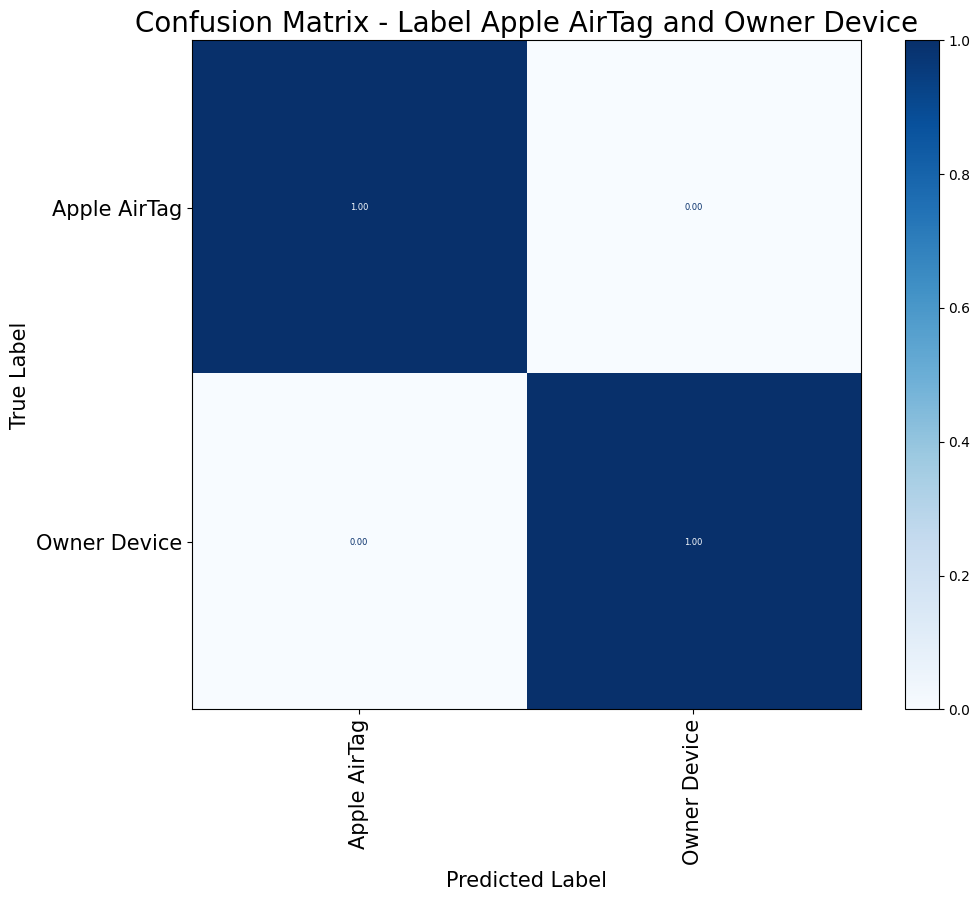

In [14]:
labeledFiles = [r"BLE Tracker\Apple Find My\Apple AirTag\Apple_AirTag_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"BLE Tracker\Apple Find My\Apple AirTag\Apple_AirTag_(nearby)_3h.csv"
]

evaluationFiles = [r"BLE Tracker\Apple Find My\Apple AirTag\Apple_AirTag_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Apple_AirTag,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Apple_AirTag])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Apple AirTag 2 and Owner Device
                precision    recall  f1-score   support

Apple AirTag 2     0.9992    1.0000    0.9996      1227
  Owner Device     1.0000    0.9999    1.0000     10138

      accuracy                         0.9999     11365
     macro avg     0.9996    1.0000    0.9998     11365
  weighted avg     0.9999    0.9999    0.9999     11365





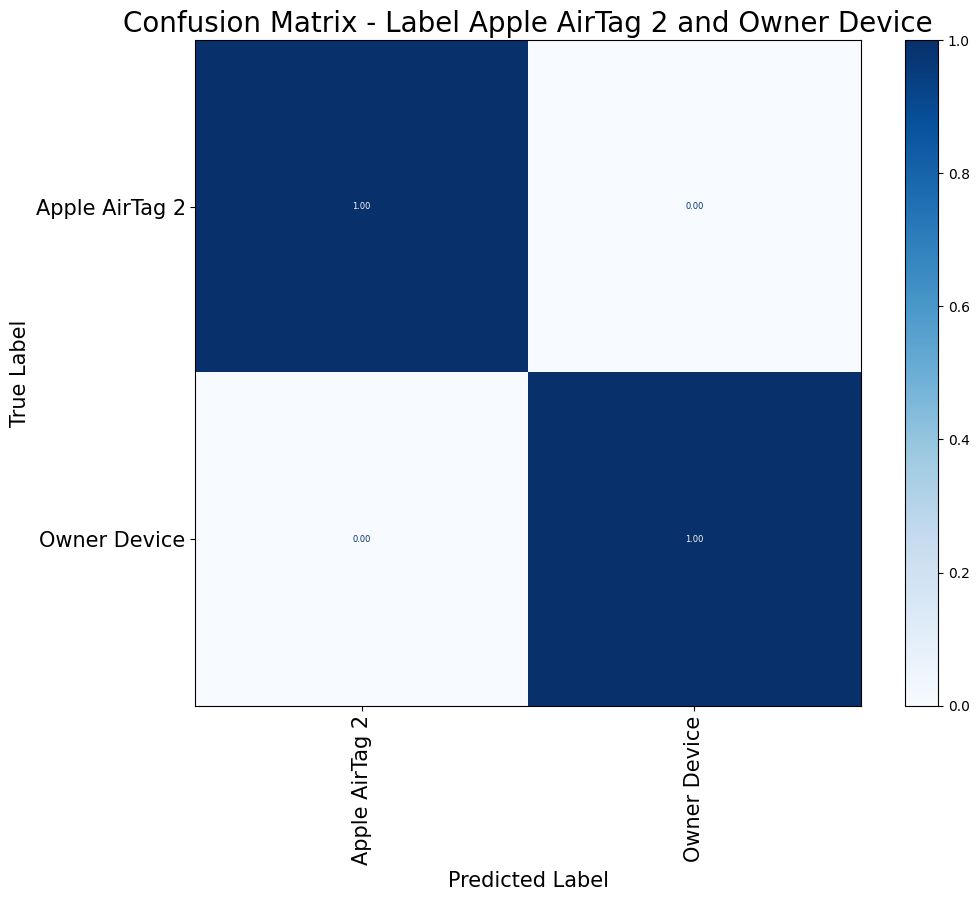

In [15]:
labeledFiles = [r"BLE Tracker\Apple Find My\Apple AirTag 2\Apple_AirTag_2_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"BLE Tracker\Apple Find My\Apple AirTag 2\Apple_AirTag_2_(nearby)_3h.csv"
]

evaluationFiles = [r"BLE Tracker\Apple Find My\Apple AirTag 2\Apple_AirTag_2_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Apple_AirTag_2,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Apple_AirTag_2])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Chipolo ONE and Owner Device
              precision    recall  f1-score   support

 Chipolo ONE     1.0000    0.9965    0.9982      1144
Owner Device     0.9996    1.0000    0.9998     10420

    accuracy                         0.9997     11564
   macro avg     0.9998    0.9983    0.9990     11564
weighted avg     0.9997    0.9997    0.9997     11564





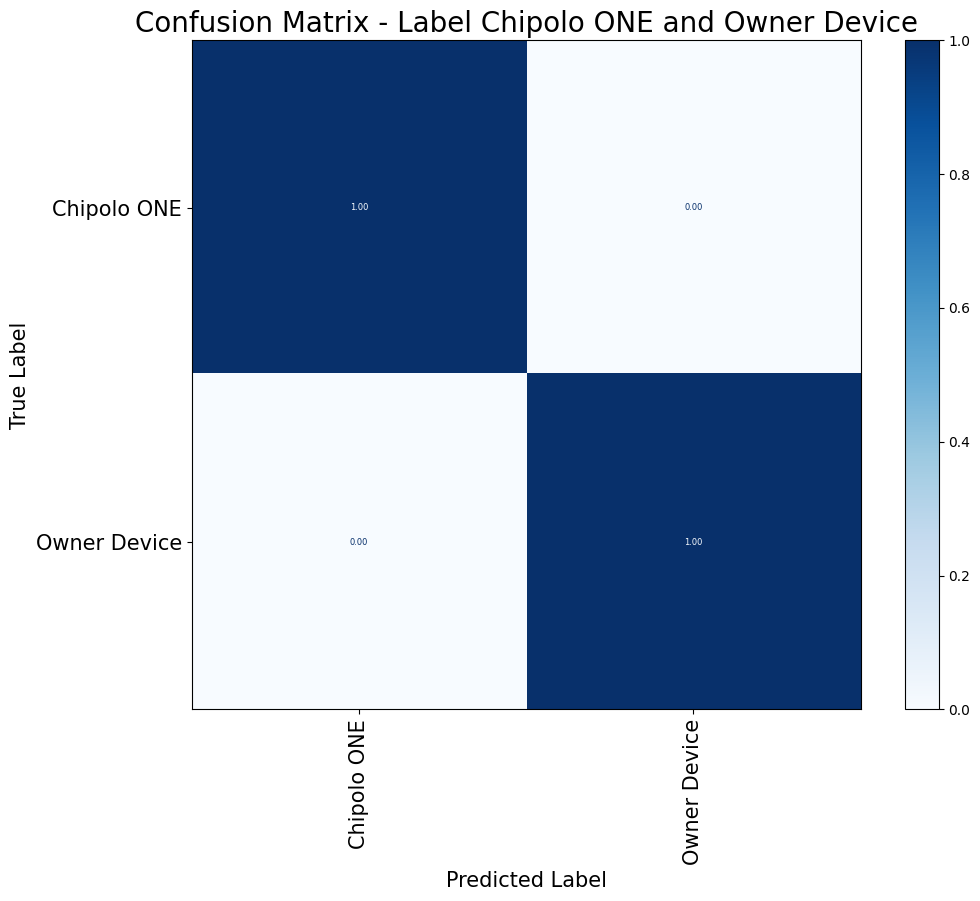

In [16]:
labeledFiles = [r"BLE Tracker\Apple Find My\Chipolo ONE\Chipolo_ONE_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"BLE Tracker\Apple Find My\Chipolo ONE\Chipolo_ONE_(nearby)_3h.csv"
]

evaluationFiles = [r"BLE Tracker\Apple Find My\Chipolo ONE\Chipolo_ONE_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Chipolo_One,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Chipolo_One])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Chipolo CARD [Apple] and Owner Device
                      precision    recall  f1-score   support

Chipolo CARD [Apple]     1.0000    0.9977    0.9988       427
        Owner Device     0.9997    1.0000    0.9999      3513

            accuracy                         0.9997      3940
           macro avg     0.9999    0.9988    0.9993      3940
        weighted avg     0.9997    0.9997    0.9997      3940





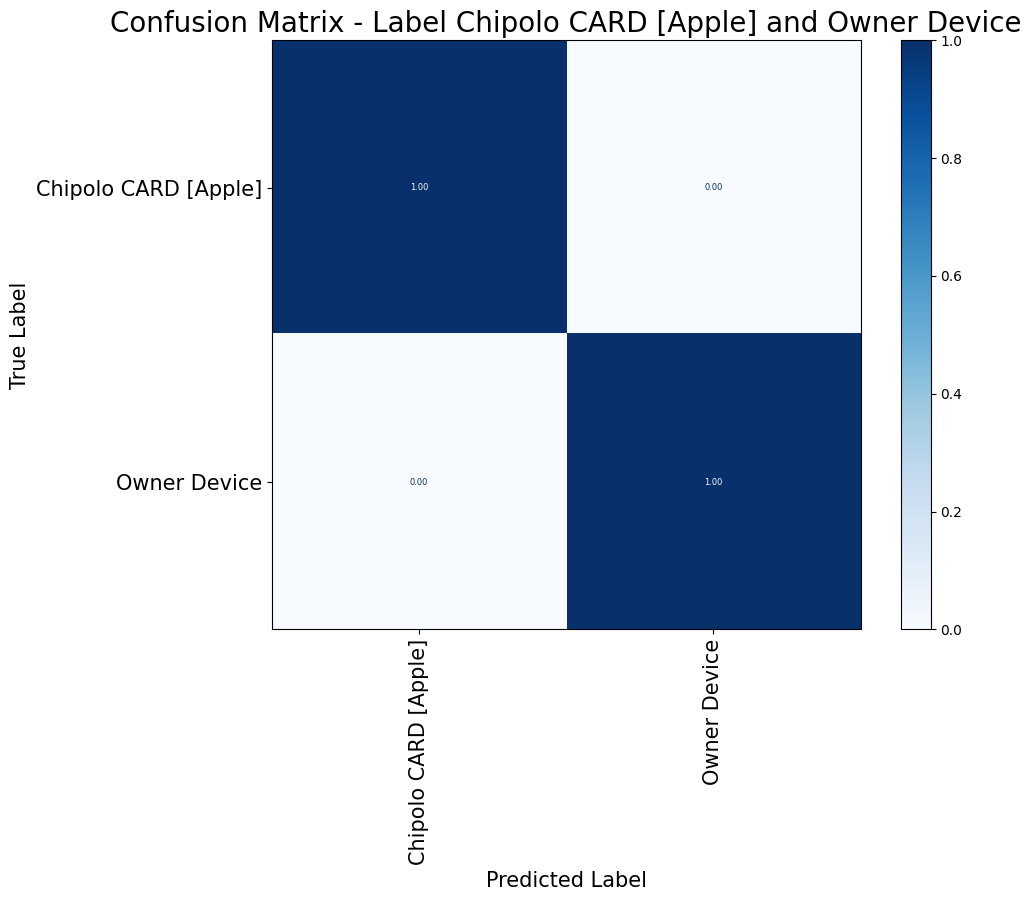

In [17]:
labeledFiles = [r"BLE Tracker\Apple Find My\Chipolo CARD\Chipolo_CARD_(nearby)_(Apple)_labeled_training.csv",
                ]

unlabeledFiles = [  ]

evaluationFiles = [r"BLE Tracker\Apple Find My\Chipolo CARD\Chipolo_CARD_(nearby)_(Apple)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Chipolo_Card_Apple,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Chipolo_Card_Apple])

taskGroup_Labeling_auto.add(task)



Classification Report - Label 4Smarts SkyTag and Owner Device
                precision    recall  f1-score   support

4Smarts SkyTag     1.0000    0.9990    0.9995       988
  Owner Device     0.9999    1.0000    0.9999      9357

      accuracy                         0.9999     10345
     macro avg     0.9999    0.9995    0.9997     10345
  weighted avg     0.9999    0.9999    0.9999     10345





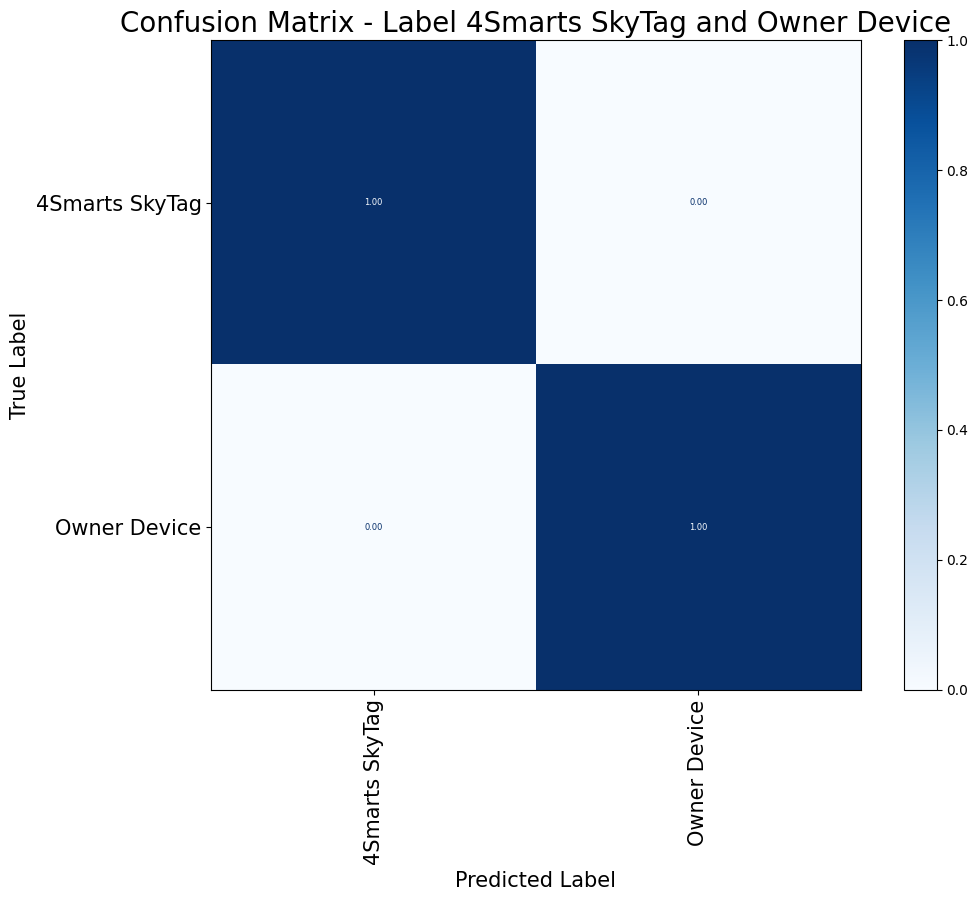

In [18]:
labeledFiles = [r"BLE Tracker\Apple Find My\4Smarts SkyTag\4Smarts_SkyTag_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"BLE Tracker\Apple Find My\4Smarts SkyTag\4Smarts_SkyTag_(nearby)_3h.csv"
]

evaluationFiles = [r"BLE Tracker\Apple Find My\4Smarts SkyTag\4Smarts_SkyTag_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_4Smarts_SkyTag,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_4Smarts_SkyTag])

taskGroup_Labeling_auto.add(task)



Classification Report - Label 4Smarts SkyTag Card and Owner Device
                     precision    recall  f1-score   support

4Smarts SkyTag Card     1.0000    0.9967    0.9984       304
       Owner Device     0.9997    1.0000    0.9999      3513

           accuracy                         0.9997      3817
          macro avg     0.9999    0.9984    0.9991      3817
       weighted avg     0.9997    0.9997    0.9997      3817





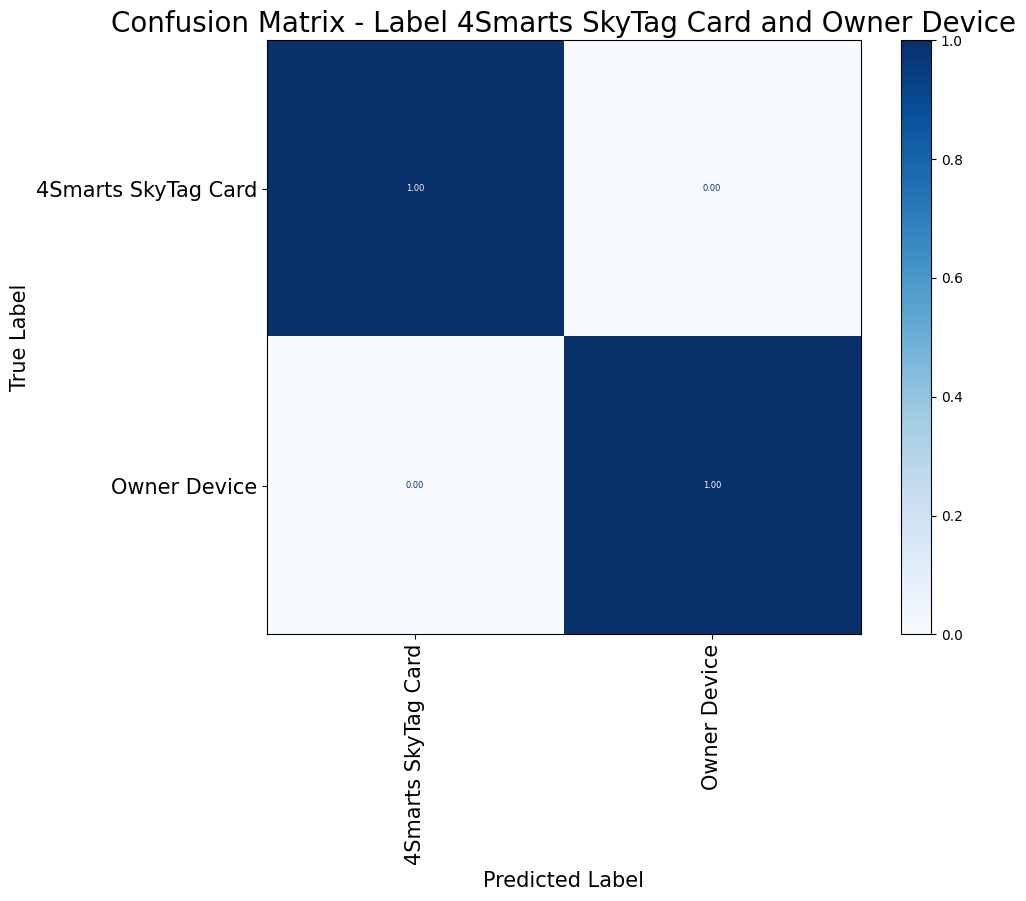

In [19]:
labeledFiles = [r"BLE Tracker\Apple Find My\4Smarts SkyTag Card\4Smarts_SkyTag_Card_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Apple Find My\4Smarts SkyTag Card\4Smarts_SkyTag_Card_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_4Smarts_SkyTag_Card,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_4Smarts_SkyTag_Card])

taskGroup_Labeling_auto.add(task)



Classification Report - Label KeySmart SmartCard and Owner Device
                    precision    recall  f1-score   support

KeySmart SmartCard     1.0000    0.9975    0.9988       408
      Owner Device     0.9997    1.0000    0.9999      3425

          accuracy                         0.9997      3833
         macro avg     0.9999    0.9988    0.9993      3833
      weighted avg     0.9997    0.9997    0.9997      3833





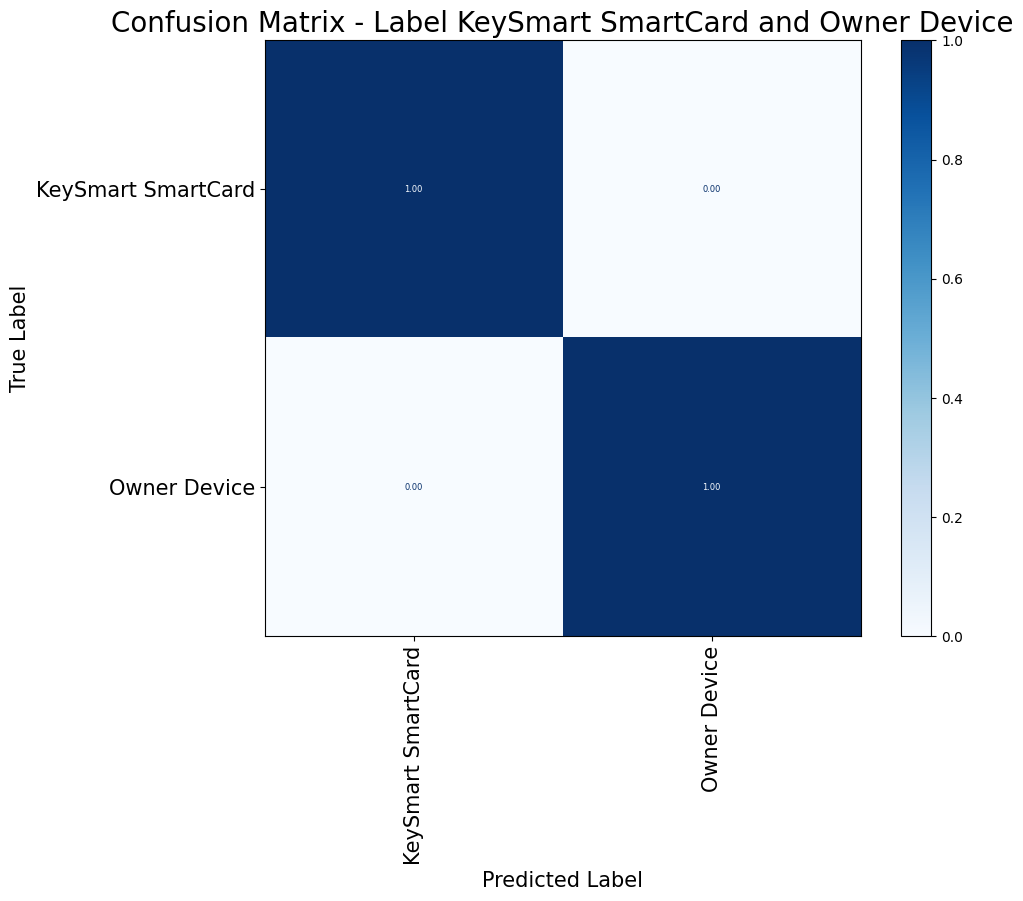

In [20]:
labeledFiles = [r"BLE Tracker\Apple Find My\KeySmart SmartCard\KeySmart_SmartCard_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  ]

evaluationFiles = [r"BLE Tracker\Apple Find My\KeySmart SmartCard\KeySmart_SmartCard_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_KeySmart_SmartCard,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_KeySmart_SmartCard])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Apple AirPod and Owner Device
              precision    recall  f1-score   support

Apple AirPod     0.9998    1.0000    0.9999      5143
Owner Device     1.0000    0.9997    0.9999      3661

    accuracy                         0.9999      8804
   macro avg     0.9999    0.9999    0.9999      8804
weighted avg     0.9999    0.9999    0.9999      8804





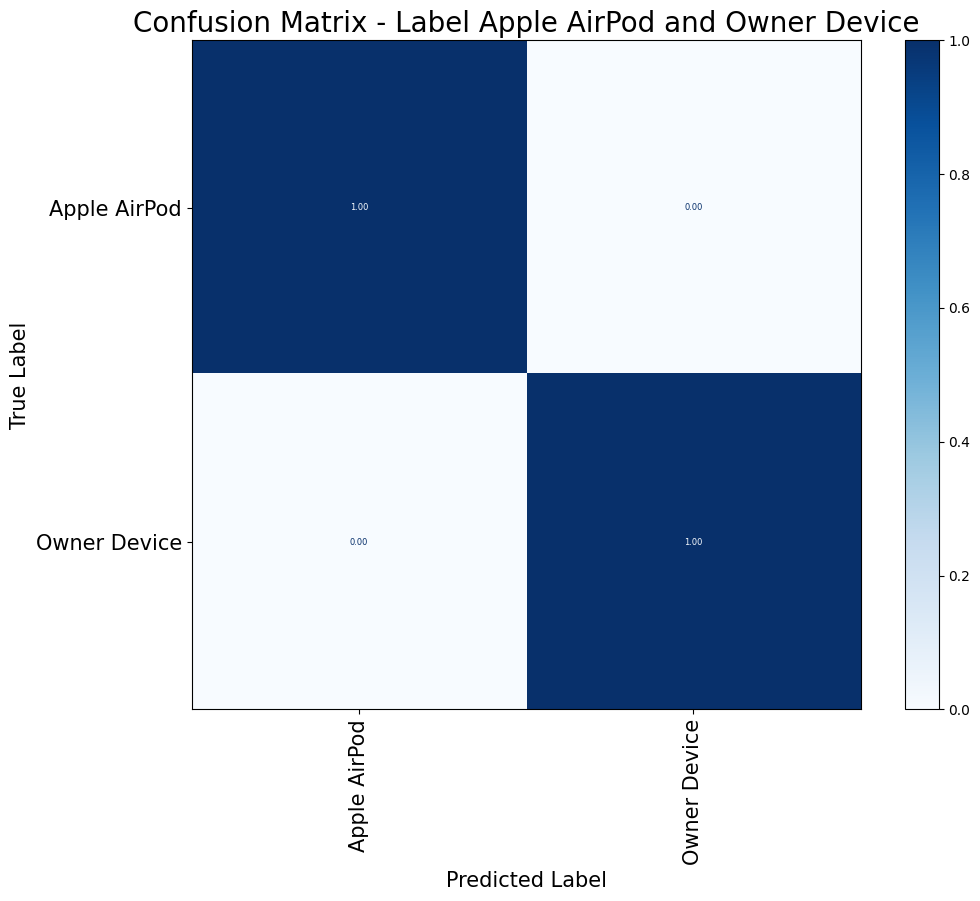

In [21]:
labeledFiles = [r"Apple iDevices\Apple AirPod\Apple_AirPod_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"Apple iDevices\Apple AirPod\Apple_AirPod_(nearby)_3h.csv"
]

evaluationFiles = [r"Apple iDevices\Apple AirPod\Apple_AirPod_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Apple_AirPod,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Apple_AirPod],
                                selection=slice(0, 50),
                                threshold=0.8)

taskGroup_Labeling_auto.add(task)

## Automatic Labeling Google Find My Hub Network Trackers



Classification Report - Label Motorola MotoTag and Owner Device
                  precision    recall  f1-score   support

Motorola MotoTag     1.0000    0.9957    0.9978      1156
    Owner Device     0.9995    1.0000    0.9998     10868

        accuracy                         0.9996     12024
       macro avg     0.9998    0.9978    0.9988     12024
    weighted avg     0.9996    0.9996    0.9996     12024





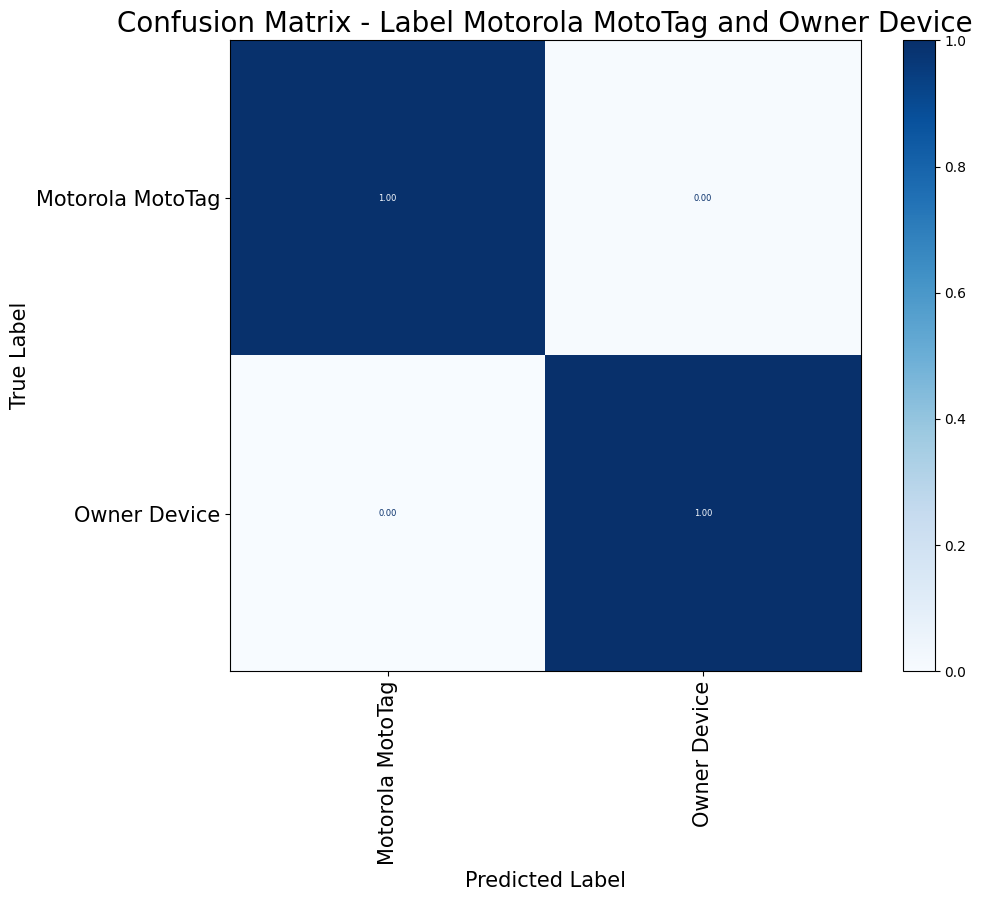

In [22]:
labeledFiles = [r"BLE Tracker\Google Find My\Motorola MotoTag\Motorola_MotoTag_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Google Find My\Motorola MotoTag\Motorola_MotoTag_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Motorola_MotoTag,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Motorola_MotoTag])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Lifemate LifeTag and Owner Device
                  precision    recall  f1-score   support

Lifemate LifeTag     1.0000    0.9886    0.9943       440
    Owner Device     0.9990    1.0000    0.9995      4796

        accuracy                         0.9990      5236
       macro avg     0.9995    0.9943    0.9969      5236
    weighted avg     0.9990    0.9990    0.9990      5236





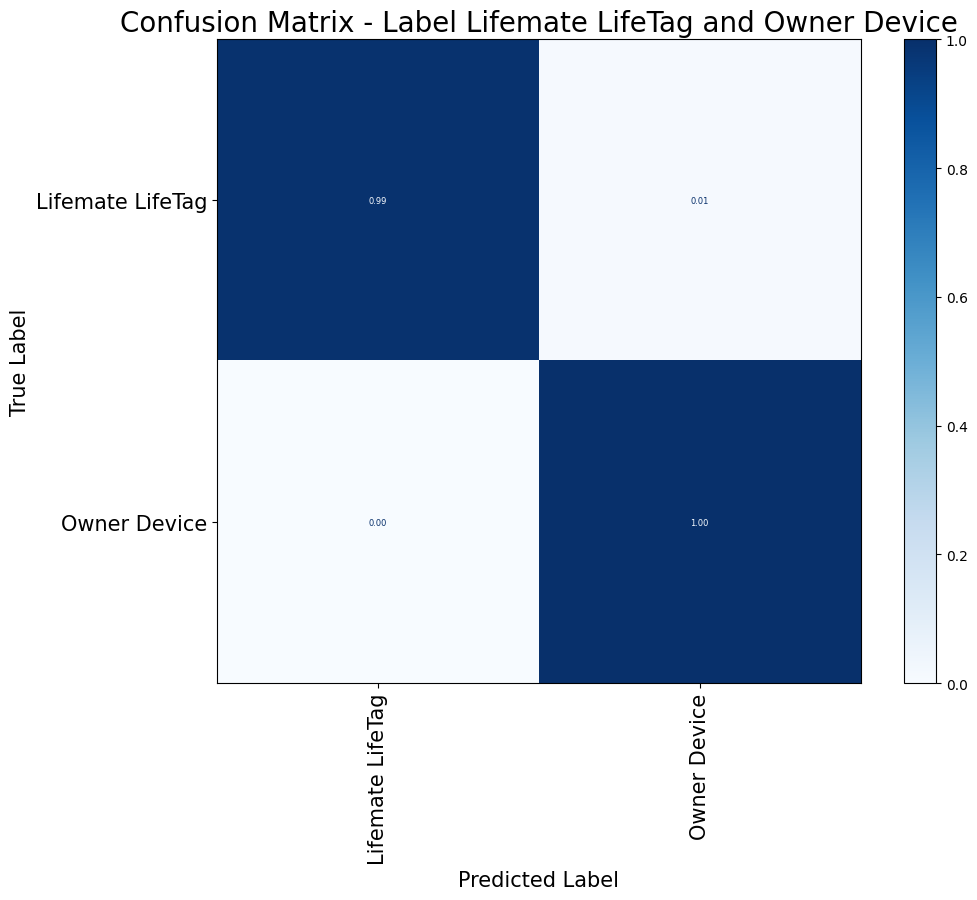

In [23]:
labeledFiles = [r"BLE Tracker\Google Find My\Lifemate LifeTag\Lifemate_LifeTag_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Google Find My\Lifemate LifeTag\Lifemate_LifeTag_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Lifemate_LifeTag,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Lifemate_LifeTag])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Hama MGF and Owner Device
              precision    recall  f1-score   support

    Hama MGF     1.0000    0.9907    0.9953       430
Owner Device     0.9992    1.0000    0.9996      4801

    accuracy                         0.9992      5231
   macro avg     0.9996    0.9953    0.9975      5231
weighted avg     0.9992    0.9992    0.9992      5231





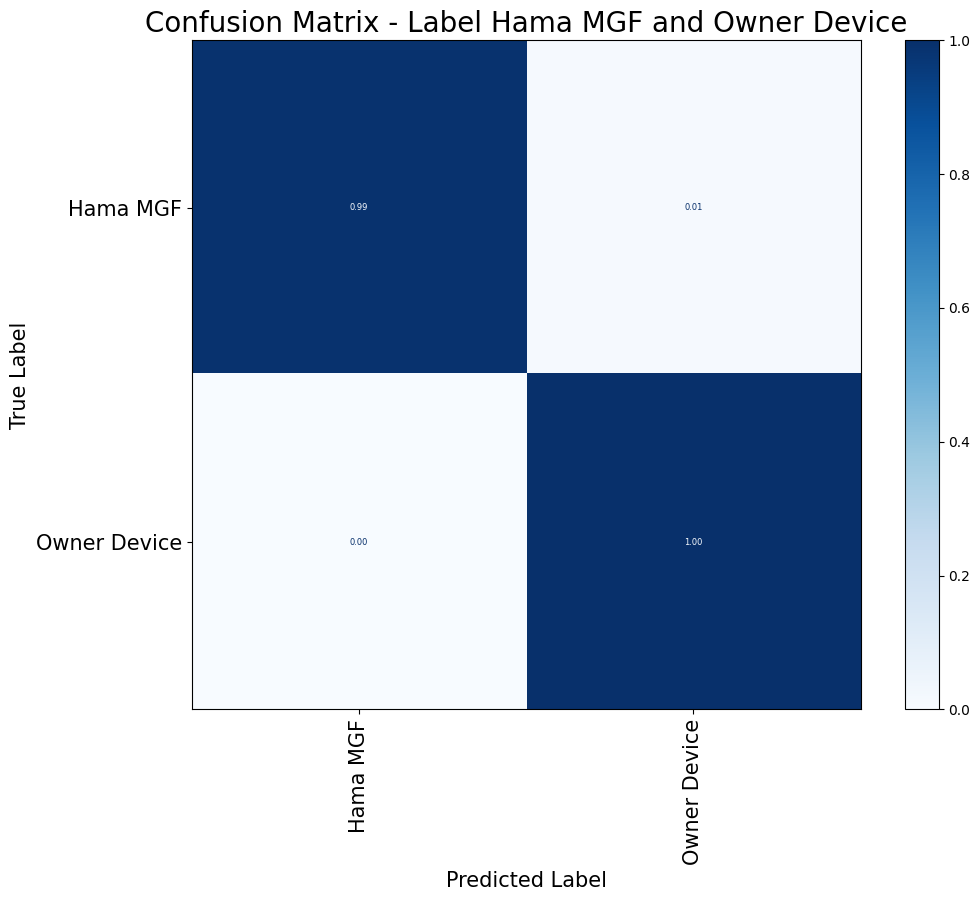

In [24]:
labeledFiles = [r"BLE Tracker\Google Find My\Hama MGF\Hama_MGF_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Google Find My\Hama MGF\Hama_MGF_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Hama_MGF,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Hama_MGF])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Chipolo CARD [Google] and Owner Device
                       precision    recall  f1-score   support

Chipolo CARD [Google]     1.0000    0.9908    0.9954       437
         Owner Device     0.9986    1.0000    0.9993      2775

             accuracy                         0.9988      3212
            macro avg     0.9993    0.9954    0.9973      3212
         weighted avg     0.9988    0.9988    0.9988      3212





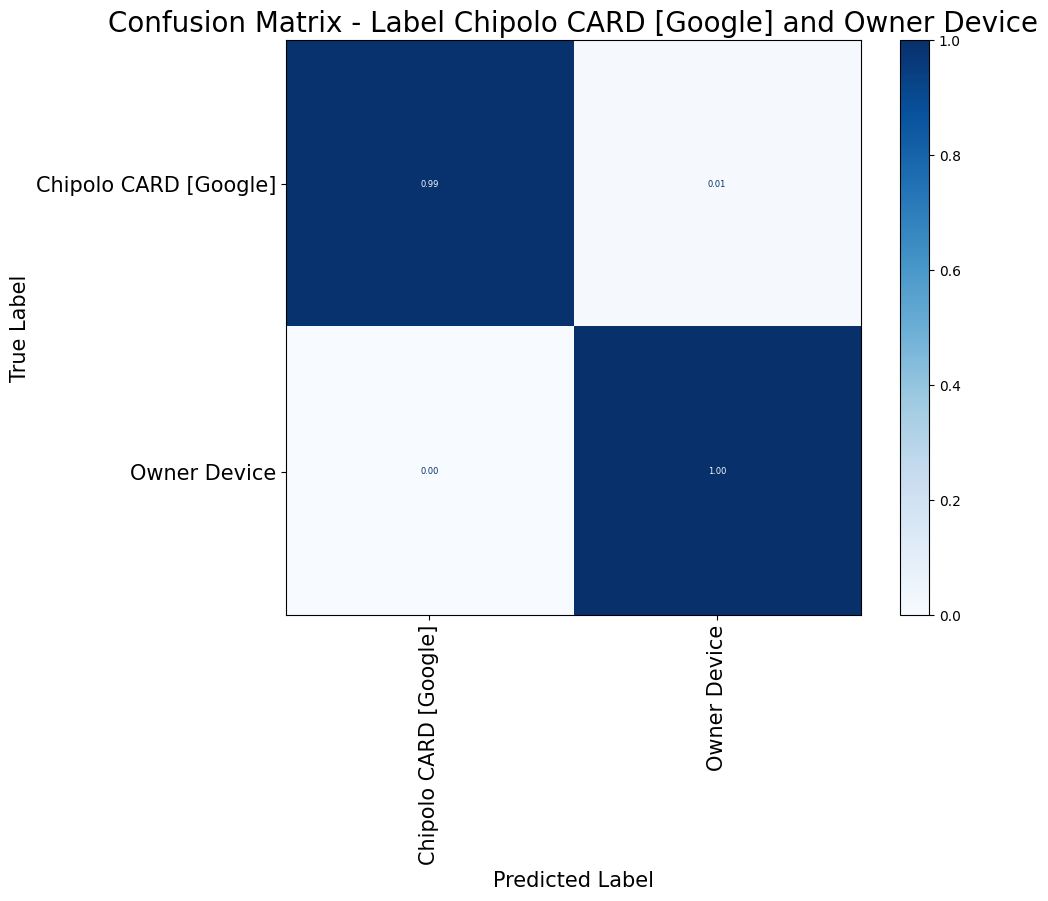

In [25]:
labeledFiles = [r"BLE Tracker\Google Find My\Chipolo Card\Chipolo_Card_(nearby)_(Google)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Google Find My\Chipolo Card\Chipolo_Card_(nearby)_(Google)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Chipolo_Card_Google,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Chipolo_Card_Google])

taskGroup_Labeling_auto.add(task)

## Automatic Labeling: Other Tracking Networks



Classification Report - Label Tile Mate and Owner Device
              precision    recall  f1-score   support

Owner Device     0.9999    1.0000    0.9999     18619
   Tile Mate     1.0000    0.9981    0.9990      1033

    accuracy                         0.9999     19652
   macro avg     0.9999    0.9990    0.9995     19652
weighted avg     0.9999    0.9999    0.9999     19652





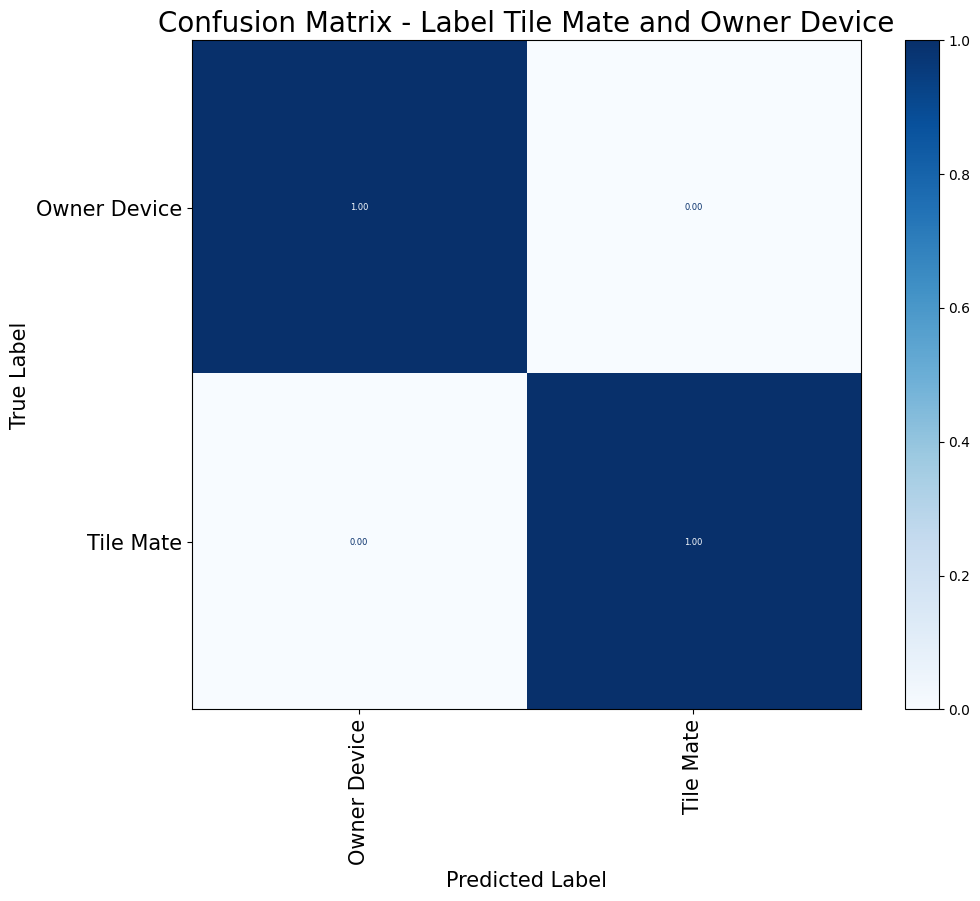

In [26]:
labeledFiles = [r"BLE Tracker\Tile\Tile Mate\Tile_Mate_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [  #r"BLE Tracker\Tile\Tile Mate\Tile_Mate_(nearby)_3h.csv"
]

evaluationFiles = [r"BLE Tracker\Tile\Tile Mate\Tile_Mate_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Tile_Mate,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Tile_Mate])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Tile Slim and Owner Device
              precision    recall  f1-score   support

Owner Device     0.9990    1.0000    0.9995      4066
   Tile Slim     1.0000    0.9911    0.9955       448

    accuracy                         0.9991      4514
   macro avg     0.9995    0.9955    0.9975      4514
weighted avg     0.9991    0.9991    0.9991      4514





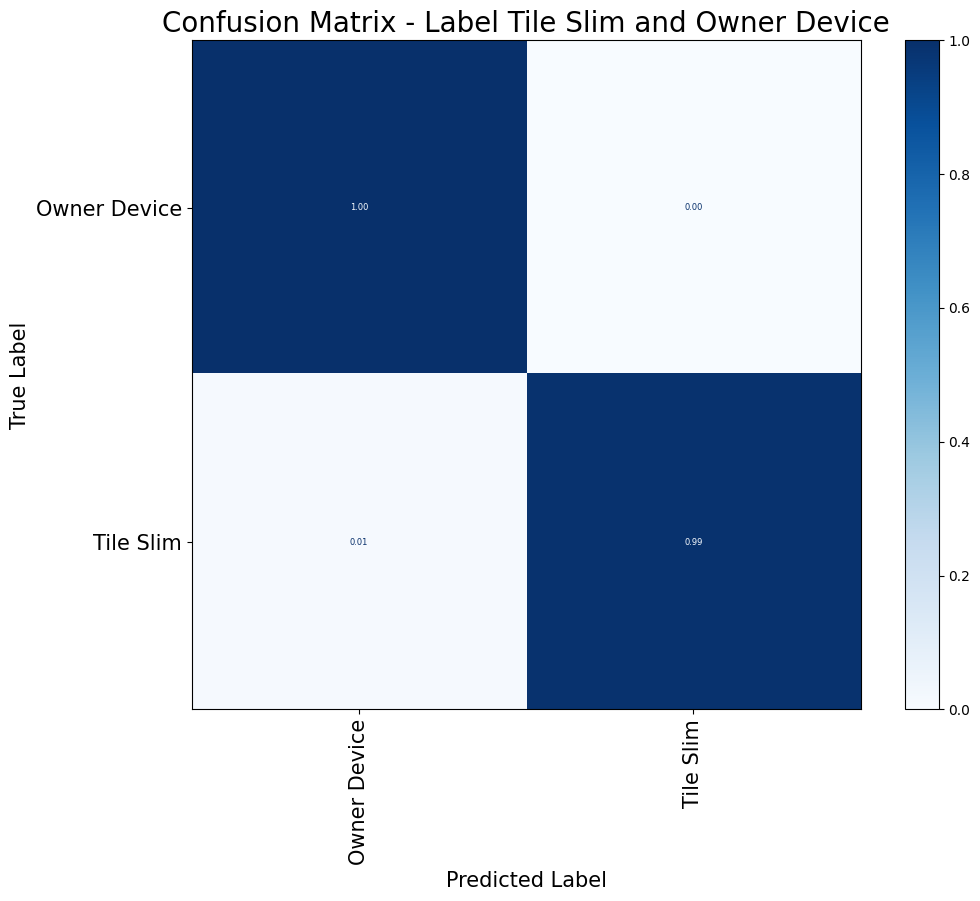

In [27]:
labeledFiles = [r"BLE Tracker\Tile\Tile Slim\Tile_Slim_(nearby)_labeled_training.csv",
                ]

unlabeledFiles = [ ]

evaluationFiles = [r"BLE Tracker\Tile\Tile Slim\Tile_Slim_(nearby)_labeled_evaluation.csv"
                   ]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_Tile_Slim,
                                secondDevice=label_owner_Device,
                                flags=nearby_label_flag_lut[label_Tile_Slim])

taskGroup_Labeling_auto.add(task)



Classification Report - Label Owner Device and Samsung SmartTag
                  precision    recall  f1-score   support

    Owner Device     0.9983    1.0000    0.9992      5413
Samsung SmartTag     1.0000    0.9703    0.9849       303

        accuracy                         0.9984      5716
       macro avg     0.9992    0.9851    0.9920      5716
    weighted avg     0.9984    0.9984    0.9984      5716





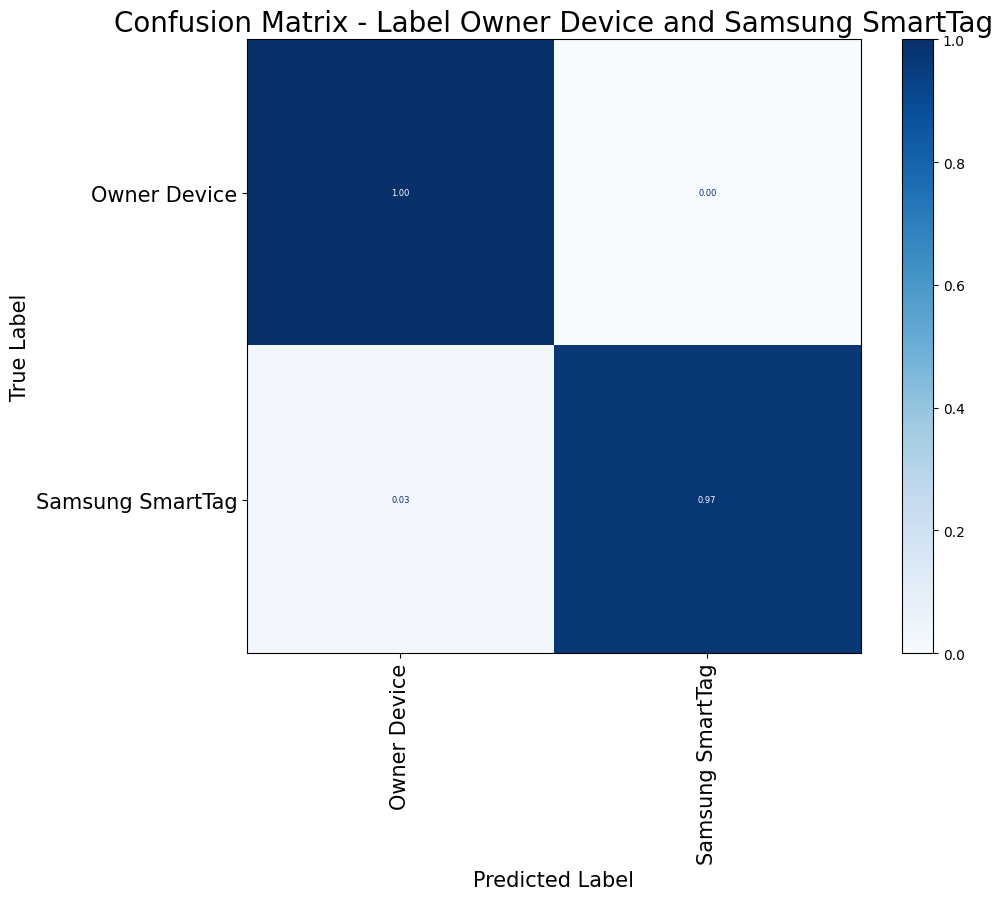

In [28]:
labeledFiles = [r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_training_V1.csv",
                r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_training_V2.csv",
                r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_training_V3.csv"
                ]

unlabeledFiles = [  #r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_3h.csv"
]

evaluationFiles = [
    r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_evaluation_V1.csv",
    r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_evaluation_V2.csv",
    r"BLE Tracker\Samsung SmartThings\Samsung SmartTag\Samsung_SmartTag_(nearby)_labeled_evaluation_V3.csv",
]

task = nearbyTrackerTaskFactory(BaseConfig=NearbyTrackerConfig,
                                labeledFiles=labeledFiles,
                                unlabeledFiles=unlabeledFiles,
                                evaluationFiles=evaluationFiles,
                                firstDevice=label_owner_Device,
                                secondDevice=label_Samsung_SmartTag,
                                flags=nearby_label_flag_lut[label_Samsung_SmartTag]
                                )

taskGroup_Labeling_auto.add(task)

In [29]:
for label in device_labels:
    task = Task("Label " + label, executor=ex.labeling(label=label), flags=label_flag_lut[label])
    taskGroup_Labeling_manual.add(task)

taskGroup_Labeling.add(taskGroup_Labeling_manual)
taskGroup_Labeling.add(taskGroup_Labeling_auto)

AnalysisPipeline.add(taskGroup_Labeling)
AnalysisPipeline.print(priority=True)

Processing Pipeline
	10 Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	30 Labeling
		10 Labeling auto
			Label Apple AirTag and Owner Device
			Label Apple AirTag 2 and Owner Device
			Label Chipolo ONE and Owner Device
			Label Chipolo CARD [Appl

In [30]:
stateColumn = 'State'

taskGroup_states = TaskGroup("States", priority=40, idempotency=True, flags=flag_states)

task_stateColumn = Task("State Column", executor=ex.instantiateStateColumn(stateColumn=stateColumn), priority=10)
task_collapseStateColumn = Task("Collapse State Column", executor=ex.collapseStateColumn(stateColumn=stateColumn))

taskGroup_states_iDevices = TaskGroup("States iDevices", priority=20, idempotency=True, flags=flag_states_iDevices)

task_findMy = Task("Continuity", executor=ex.addStateContinuityType(labelColumn="Label",
                                                                    typeColumn="Continuity Type",
                                                                    types=continuityTypes,
                                                                    MS_DataColumn_Length='Length MS Data',
                                                                    strike=100,
                                                                    seperator=' ',
                                                                    stateColumn='State',
                                                                    labels=labels_iDevices)
                   )

task_offline = Task("offline",
                    executor=ex.addState(stateColumn=stateColumn, stateLabel="(offline)", labels=labels_iDevices),
                    flags=flag_state_offline)
task_online = Task("online",
                   executor=ex.addState(stateColumn=stateColumn, stateLabel="(online)", labels=labels_iDevices),
                   flags=flag_state_online)

taskGroup_states_iDevices.addAll([task_findMy, task_online, task_offline])

taskGroup_states_Trackers = TaskGroup("States Trackers", priority=30, idempotency=True, flags=flag_states_Tracker)

task_lost = Task("lost", executor=ex.addState(stateColumn=stateColumn, stateLabel="(lost)",
                                              labels=labels_trackers + [label_Apple_AirPod]), flags=flag_state_lost)
task_nearby = Task("nearby", executor=ex.addState(stateColumn=stateColumn, stateLabel="(nearby)",
                                                  labels=labels_trackers + [label_Apple_AirPod]),
                   flags=flag_state_nearby)
task_unpaired = Task("unpaired",
                     executor=ex.addState(stateColumn=stateColumn, stateLabel="(unpaired)", labels=labels_trackers),
                     flags=flag_state_unpaired)
task_searching = Task("searching",
                      executor=ex.addState(stateColumn=stateColumn, stateLabel="(searching)", labels=labels_trackers),
                      flags=flag_state_searching)

taskGroup_states_Trackers.addAll([task_lost, task_nearby, task_unpaired, task_searching])

taskGroup_states.addAll(
    [task_stateColumn, task_collapseStateColumn, taskGroup_states_iDevices, taskGroup_states_Trackers])

taskGroup_states.print(priority=True, flags=True)

40 States: States
	10 State Column
	20 States iDevices: States iDevices
		Continuity
		online: State online
		offline: State offline
	30 States Trackers: States Tracker
		lost: State lost
		nearby: State nearby
		unpaired: State unpaired
		searching: State searching
	Collapse State Column


In [31]:
AnalysisPipeline.add(taskGroup_states)
AnalysisPipeline.print(priority=True, flags=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	30 Labeling: Labeling
		10 Labeling auto: Labeling auto
			Label Apple AirTag and Owner Device: Label Apple AirTag and nearby Owner Device
			

In [32]:
import pickle

with open(picklePath + AnalysisPipeline.getName() + '.pickle', 'wb') as f:
    pickle.dump(AnalysisPipeline, f)

In [33]:
flags = list(set(flags))

for flag in flags:
    with open(picklePath + flag.getName() + '.pickle', 'wb') as f:
        pickle.dump(flag, f)


In [34]:
temp = AnalysisPipeline.process(data.copy(deep=True), flag=Flag(name='Run', parents=[flag_preProcessing, flag_dummy,
                                                                                     label_flag_lut[label_other_Device],
                                                                                     flag_states_iDevices]))
temp.info()

<class 'pandas.DataFrame'>
Index: 597429 entries, 0 to 597428
Data columns (total 43 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   Time                                        597429 non-null  datetime64[ns]
 1   Source                                      597429 non-null  str           
 2   Length Packet                               597429 non-null  int64         
 3   Length Header                               597429 non-null  int64         
 4   Length MS Data                              597429 non-null  int64         
 5   Continuity Type                             597429 non-null  string        
 6   Length Service Data                         597429 non-null  int64         
 7   Broadcast                                   597429 non-null  int64         
 8   CH 37                                       597429 non-null  int64         
 9   CH 38    

In [35]:
temp

,Time,Source,Length Packet,Length Header,Length MS Data,Continuity Type,Length Service Data,Broadcast,CH 37,CH 38,...,CT 09,CT 10,CT 12,CT 16,CT Other,ST 1,ST 3,ST 5,ST Other,Label
0,2024-03-19 10:09:31.183264017,42:20:9d:12:ac:21,50,24,64,10,0,1,0,0,...,0,1,0,0,0,0,0,0,0,other Device
1,2024-03-19 10:09:31.183264017,7b:ce:90:62:13:14,49,23,80,16,0,1,1,0,...,0,0,0,1,0,0,0,0,0,other Device
2,2024-03-19 10:09:31.183264017,7b:ce:90:62:13:14,49,23,80,16,0,1,0,1,...,0,0,0,1,0,0,0,0,0,other Device
3,2024-03-19 10:09:31.183264017,7b:ce:90:62:13:14,49,23,80,16,0,1,0,0,...,0,0,0,1,0,0,0,0,0,other Device
4,2024-03-19 10:09:31.183264017,cb:6c:88:f2:c3:ce,40,14,32,12,0,1,1,0,...,0,0,1,0,0,0,0,0,0,other Device
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597424,2024-03-19 22:09:30.940131903,63:7c:c1:f9:3a:b2,50,24,64,10,0,1,0,1,...,0,1,0,0,0,0,0,0,0,other Device
597425,2024-03-19 22:09:30.940772057,63:7c:c1:f9:3a:b2,50,24,64,10,0,1,0,0,...,0,1,0,0,0,0,0,0,0,other Device
597426,2024-03-19 22:09:31.219496012,63:7c:c1:f9:3a:b2,50,24,64,10,0,1,1,0,...,0,1,0,0,0,0,0,0,0,other Device
597427,2024-03-19 22:09:31.220134974,63:7c:c1:f9:3a:b2,50,24,64,10,0,1,0,1,...,0,1,0,0,0,0,0,0,0,other Device
